### Tools in LangChain



#### 1. Overview of the Agents Segment
This video starts the third part of the LangChain playlist. The upcoming topics are:
1.  **Tools** (This video)
2.  **Tool Calling** (Next video)
3.  **Agents** (Following videos)

---

#### 2. What are Tools?

- **The Problem with LLMs:**
    - LLMs have two core capabilities: **Reasoning** (thinking) and **Language Generation** (speaking).
    - They **cannot perform actions** on their own. They can't book a train, fetch live weather data, reliably solve complex math, or call external APIs.
    - Think of an LLM as a human body with a brain and a mouth, but no hands or legs.

- **The Solution: Tools**
    - **Tools are a mechanism to give LLMs "hands and legs".** They allow an LLM to perform actions.
    - Technically, **a tool is just a Python function packaged in a way that an LLM can understand and call when needed.**
    - The LLM can decide which tool to use, provide it with the necessary input, and the tool will execute the task and return the result to the LLM.
---

#### 3. Types of Tools in LangChain

There are two main types of tools you will work with:

1.  **Built-in Tools:** Pre-built tools provided by LangChain for common use-cases (e.g., Google Search, Wikipedia, Shell commands). You can simply import and use them.
<img src="Screenshot 2026-09-05 at 4.20.19 PM.png">
2.  **Custom Tools:** Tools you create yourself for specific tasks not covered by built-in tools (e.g., interacting with your company's internal API, encapsulating a unique business logic).

---

#### 4. How Tools Relate to Agents

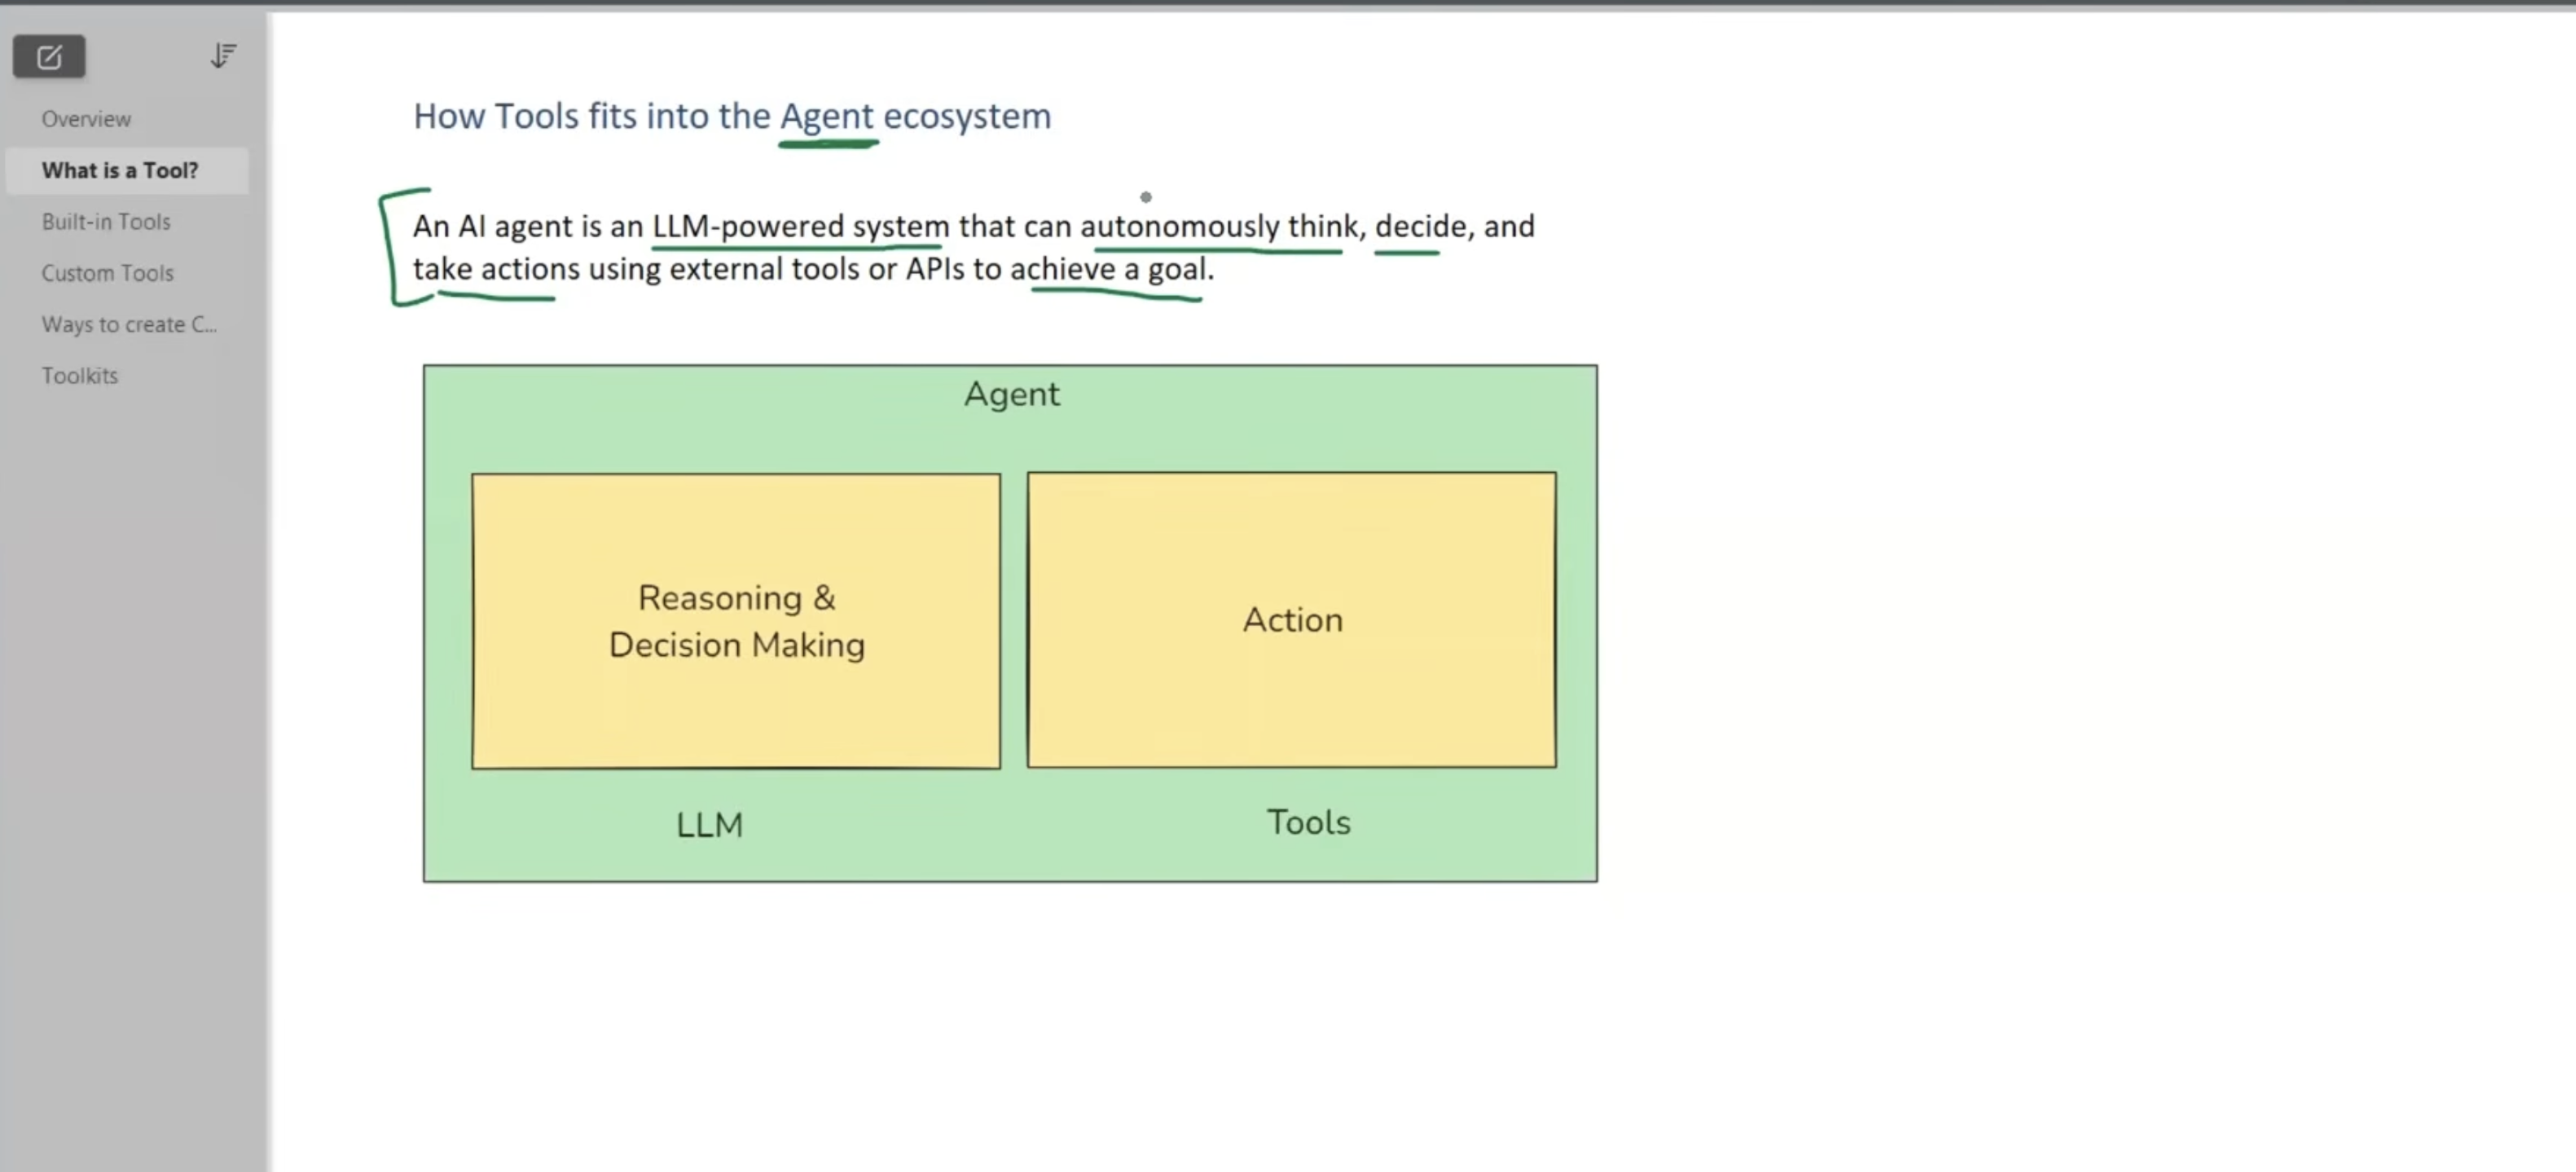
- **An AI Agent** is an LLM-powered system that can **autonomously think, decide, and take actions** using external tools/APIs to achieve a goal.
- **Agent = LLM (Reasoning) + Tools (Acting)**
- An agent uses the LLM's reasoning to decide *what* to do and then uses a *tool* to actually *do* it.

---

#### 5. Working with Built-in Tools

Here's how to use a built-in tool, using `DuckDuckGoSearchRun` as an example.

**Explanation:**
We import the tool from `langchain_community.tools`, create an instance, and then call the `invoke` method with a search query.

In [ ]:
# Install necessary package if not already installed
# !pip install langchain-community duckduckgo-search
# !pip install langchain langchain-core langchain-community pydantic duckduckgo-search langchain_experimental

## Built-in Tool - DuckDuckGo Search

## THese tools are runnables so u can use invoke method

In [ ]:
# !pip install -U ddgs

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

#Create an instance of the tool
search_tool=DuckDuckGoSearchRun()


# Invoke the tool with a search query
results=search_tool.invoke("top news in nepal today")

# Print the result
print(results)

1 day ago - The UN has raised fresh alarm over the climate crisis at the Pacific Islands Forum in Palau, amid China-Taiwan tensions. ... Nepal authorities are burying unidentified flood victims in temporary graves. ... KATHMANDU: The recent catastrophic floods along the Bhote Koshi corridor... ... KATHMANDU: The recent catastrophic floods along the Bhote Koshi corridor have served as a harrowing wake-up call for Nepal and the broader South Asian region. 11 hours ago - South Asian correspondent Azadeh Moshiri is at the site of a tunnel where rescuers still hope to find survivors following the Nepal-Tibet floods. ... Claire Tamang says electricity is interrupted and food prices are rising as thousands of people remain missing. At a gathering held in place of Isha Foundation’s cancelled programme, Sadhguru urges Ne... Nvidia donates $10 million to flood recovery, one of Nepal’s biggest corporate donations 18 hours ago - Search-and-rescue operations continue in Nepal after a partial glacie

**Another Example: `ShellTool`**
This tool allows you to run command-line commands.

In [3]:
# # !pip install langchain-experimental  # Required for ShellTool

In [ ]:
from langchain_community.tools import ShellTool

shell_tool=ShellTool()
# Invoke the tool with a shell command
results=shell_tool.invoke("whoami") # or use ls command

print(results)
#output :(Note: This will show the username of the machine where the code is running.)

Executing command:
 whoami
kristalshrestha



**Finding More Built-in Tools:**
LangChain has a wide variety of built-in tools for search, coding, productivity, databases, etc. You can explore the full list in the LangChain documentation.


#### 6. Creating Custom Tools
<img src="Screenshot 2026-09-05 at 6.09.43 PM.png">
There are three main ways to create custom tools.
<img src="Screenshot 2026-09-05 at 6.18.41 PM.png">

We'll look at the simplest first.

##### Method 1: Using the `@tool` Decorator (Simplest)
This is the most straightforward method for creating a tool.

**Explanation:**
1.  Write a normal Python function.
2.  **Add a docstring.** This will become the tool's description, helping the LLM understand what it does.
3.  **Add type hints.** This helps the LLM understand what input to provide.
4.  **Decorate the function with `@tool`.** This converts it into a LangChain tool.

In [8]:
from langchain_core.tools import tool

# Step 1, 2, 3, and 4: Define the function and decorate it with @tool
@tool
def multiply(a:int,b:int)->int:
    """Multiplies two numbers"""
    return a * b


# The function `multiply` is now a tool.
# It has attributes like .name, .description, and .args
# Check its attributes
print(f"Tool Name: {multiply.name}")
print(f"Tool Description: {multiply.description}")
print(f"Tool Arguments: {multiply.args}")


# You can use the tool directly by calling its .invoke method and provide dictionary with inputs required to that function
result=multiply.invoke({"a":3,"b":5})
print(result)

Tool Name: multiply
Tool Description: Multiplies two numbers
Tool Arguments: {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
15


**What the LLM Sees:**
When you connect this tool to an LLM, the LLM doesn't see the function code. Instead, it sees a **JSON schema** of the tool.


In [10]:
print(multiply.args_schema.model_json_schema())

{'description': 'Multiplies two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


**Output (Example - Formatted):**
```json
{
  "title": "multiply",
  "description": "Multiplies two numbers.",
  "type": "object",
  "properties": {
    "a": {"title": "A", "type": "integer"},
    "b": {"title": "B", "type": "integer"}
  },
  "required": ["a", "b"]
}
```

##### Method 2: Using `StructuredTool` and Pydantic (More Robust)

A **Structured Tool** in Langchain is a special type of tool where the input to the tool follows a structured schema ,typically defined using a pydantic model
This method allows you to enforce a strict input schema using Pydantic models.

**Explanation:**
1.  Define a Pydantic model for the tool's input arguments.
2.  Define the function logic.
3.  Use `StructuredTool.from_function` to create the tool, passing the function, name, description, and the Pydantic model as the `args_schema`.

In [ ]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel,Field
from typing import Annotated,Literal

# 1. Define the Pydantic model for the input
class MultiplyInput(BaseModel):
    a:Annotated[int,Field(...,description="First number")]
    b:Annotated[int,Field(...,description="second number")]

# 2. Define the function logic
def multiply(a:int,b:int)->int:
    """Multiply two numbers"""
    return a*b

#3.Create a StucturedTool
multiply_tool=StructuredTool(
    func=multiply, # above defined function
    name="multiply_tool",
    description="Multiply two numbers",
    args_schema=MultiplyInput, #This enforces the schema using pydantic model
)


#Use the tool
result=multiply_tool.invoke(
    {
        "a":2,
        "b":3
    }
)
print(result) #Output:6

6


##### Method 3: Subclassing the `BaseTool` Class (Most Flexible)

`**BaseTool**` is the abstract class for all tools in LangChain.It defines the core structure and interface that any tool must follow,whether its simple one-liner or fully customized function.
All other tools types like `**@tool, StructuredTool**` are built om top of BaseTool.



This method gives you maximum control, allowing you to create synchronous and asynchronous versions of your tool.

**Explanation:**
1.  Define a new class that inherits from `BaseTool`.
2.  Define the `name`, `description`, and `args_schema` attributes.
3.  Implement the `_run` method for synchronous execution (and optionally `_arun` for async).

In [ ]:
from langchain_core.tools import BaseTool
from typing import Type,Annotated
from pydantic import BaseModel,Field

# Define a input schema (Pydantic Model)
class MultiplyInput(BaseModel):
    a:Annotated[int,Field(...,description="The first number to multiply")]
    b:Annotated[int,Field(...,description="The second number to multiply")]

# 2. Create a class that inherits from BaseTool
class MultiplyTool(BaseTool):
    name:str="multiply"
    description:str="Multiply two numbers"
    args_schema:Type[BaseModel]=MultiplyInput #This enforces the schema using pydantic model

    #3 Implement the _run method
    def _run(self,a:int,b:int)->int:
        """Synchronous method to multiply two numbers"""
        return a*b
    
    # Optional: Implement an async version
    # async def _arun(self, a: int, b: int) -> int:
    #     """Async version."""
    #     return a * b


# Use the Tool
my_tool=MultiplyTool()
result=my_tool.invoke({"a":2,"b":3})
print(result) #Ouput:6

6


#### 7. Toolkits

- **Definition:** A **Toolkit** is a collection of related tools that serve a common purpose.
- **Purpose:** It promotes reusability and convenience. You can package related tools together and use them across different applications.
- **Example:** A `GoogleDriveToolkit` might contain tools to upload, search, and read files.
<img src="Screenshot 2026-09-05 at 7.13.46 PM.png">
**Creating a Custom Toolkit:**

**Explanation:**
1.  Create the individual tools (using any of the methods above).
2.  Define a new class for your toolkit.
3.  Inside this class, create a method called `get_tools()` that returns a list of the related tools.

# First, create two related tools (e.g., for arithmetic)
# Custom tools

-  # 1st tool  for Multiply

In [10]:

# 1st tool  for Multiply
from langchain_core.tools import BaseTool
from typing import Type,Annotated
from pydantic import BaseModel,Field

# Define a input schema (Pydantic Model)
class MultiplyInput(BaseModel):
    a:Annotated[int,Field(...,description="The first number to multiply")]
    b:Annotated[int,Field(...,description="The second number to multiply")]

# 2. Create a class that inherits from BaseTool
class MultiplyTool(BaseTool):
    name:str="multiply"
    description:str="Multiply two numbers"
    args_schema:Type[BaseModel]=MultiplyInput #This enforces the schema using pydantic model

    #3 Implement the _run method
    def _run(self,a:int,b:int)->int:
        """Synchronous method to multiply two numbers"""
        return a*b
    
    # Optional: Implement an async version
    # async def _arun(self, a: int, b: int) -> int:
    #     """Async version."""
    #     return a * b




- # 2nd tool  for add

In [11]:
# 2nd tool  for add



# Define a input schema (Pydantic Model)
class AddInput(BaseModel):
    a:Annotated[int,Field(...,description="The first number to add")]
    b:Annotated[int,Field(...,description="The second number to add")]

# 2. Create a class that inherits from BaseTool
class AddTool(BaseTool):
    name:str="add"
    description:str="add two numbers"
    args_schema:Type[BaseModel]=AddInput #This enforces the schema using pydantic model defined above

    #3 Implement the _run method
    def _run(self,a:int,b:int)->int:
        """Synchronous method to add two numbers"""
        return a+b
    
    # Optional: Implement an async version
    # async def _arun(self, a: int, b: int) -> int:
    #     """Async version."""
    #     return a + b




# Now, create the toolkit consisting both those 2 tools

In [12]:
class MathToolkit():
    def get_tools(self):
        """Return the list of tools in this toolkit"""
        return [MultiplyTool(),AddTool()]

#Use the toolkit
math_tools=MathToolkit()
all_math_tools=math_tools.get_tools()

# You can now use all tools in the toolkit
for tool in all_math_tools:
    print(f"Tool Name: {tool.name}")
    print(f"Tool Description: {tool.description}\n")

Tool Name: multiply
Tool Description: Multiply two numbers

Tool Name: add
Tool Description: add two numbers

